# DecPyMC-3-Multi-Attribute : Utilite Multi-Attributs
**Serie** : Programmation Probabiliste avec PyMC (3/7)  
**Duree estimee** : 50 minutes  
**Prerequis** : [DecPyMC-2-Utility-Money](DecPyMC-2-Utility-Money.ipynb) (utilite de l'argent, aversion au risque)

---

## Objectifs

- Modeliser des decisions avec **plusieurs criteres**
- Comprendre l'**independance preferentielle**
- Appliquer les **theoremes d'additivite et multiplicativite**
- Utiliser la methode **SMART** pour la decision multi-criteres
- Inferer les **poids MAUT** par apprentissage bayesien avec PyMC

---

## Navigation

| Precedent | Suivant |
|-----------|--------|
| [DecPyMC-2-Utility-Money](DecPyMC-2-Utility-Money.ipynb) | [DecPyMC-4-Decision-Networks](DecPyMC-4-Decision-Networks.ipynb) |

## 1. Introduction : Decisions Multi-Criteres

### Le probleme

La plupart des decisions reelles impliquent plusieurs criteres :

| Decision | Criteres |
|----------|----------|
| Achat voiture | Prix, securite, consommation, confort |
| Choix de carriere | Salaire, equilibre vie/travail, passion, securite emploi |
| Investissement | Rendement, risque, liquidite, impact ESG |

Comment combiner ces criteres en une **decision rationnelle** ?

### Approches possibles

1. **Methode lexicographique** : Trier par critere le plus important, puis par le second...
2. **Ponderation simple** : V(x) = $\sum w_i \times v_i(x_i)$
3. **Theorie de l'utilite multi-attributs (MAUT)** : Fondee sur les axiomes d'utilite esperee de **von Neumann & Morgenstern (1944)** etendue au cas multi-attributs

### Preparation de l'environnement

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC version : {pm.__version__}")
print(f"ArviZ version : {az.__version__}")

PyMC version : 5.28.5
ArviZ version : 0.23.4


### Jeu de donnees : choix de voiture

Nous definissons 4 options de voiture avec 4 attributs (prix, securite, consommation, confort). Aucune ne domine sur tous les criteres, ce qui necessite une methode de decision multi-criteres structuree.

In [2]:
@dataclass
class Voiture:
    nom: str
    prix: float          # EUR
    securite: int        # 1-5 etoiles
    consommation: float  # L/100km
    confort: int         # 1-10

voitures = [
    Voiture("Economique A", 15000, 3, 5.0, 6),
    Voiture("Familiale B",  28000, 5, 6.5, 8),
    Voiture("Sport C",     45000, 4, 9.0, 7),
    Voiture("Hybride D",   32000, 5, 4.0, 8),
]

print("Options disponibles :\n")
print(f"{'Nom':<16} | {'Prix':>8} | {'Securite':>8} | {'Conso':>6} | {'Confort':>7}")
print("-" * 16 + "-+-" + "-" * 8 + "-+-" + "-" * 8 + "-+-" + "-" * 6 + "-+-" + "-" * 7)
for v in voitures:
    print(f"{v.nom:<16} | {v.prix:>8,.0f} | {v.securite:>8} | {v.consommation:>6.1f} | {v.confort:>7}")

Options disponibles :

Nom              |     Prix | Securite |  Conso | Confort
-----------------+----------+----------+--------+--------
Economique A     |   15,000 |        3 |    5.0 |       6
Familiale B      |   28,000 |        5 |    6.5 |       8
Sport C          |   45,000 |        4 |    9.0 |       7
Hybride D        |   32,000 |        5 |    4.0 |       8


### Interpretation du tableau des options

| Voiture | Profil | Points forts | Points faibles |
|---------|--------|--------------|----------------|
| **Economique A** | Budget-friendly | Prix bas, bonne conso | Securite moyenne, confort limite |
| **Familiale B** | Equilibree | Securite max, bon confort | Prix eleve, consommation moyenne |
| **Sport C** | Performance | Securite correcte | Prix tres eleve, forte conso |
| **Hybride D** | Eco-responsable | Securite max, conso min | Prix assez eleve |

> **Observation cle** : Aucune voiture ne domine les autres sur tous les criteres. C'est precisement ce type de situation qui necessite une methode de decision multi-criteres structuree.

## 2. Fonctions de Valeur vs Fonctions d'Utilite

### Distinction importante

| Type | Contexte | Propriete |
|------|----------|----------|
| **Fonction de valeur V(x)** | Certitude | Preferences sur outcomes certains |
| **Fonction d'utilite U(x)** | Incertitude | Preferences sur loteries |

### En multi-attributs

- **Valeur** : V(prix, securite, conso, confort) represente vos preferences sous certitude
- **Utilite** : U(.) integre en plus votre aversion au risque sur chaque attribut

Dans ce notebook, nous commencerons par les fonctions de valeur (plus simples), puis passerons aux fonctions d'utilite.

## 3. Independance Preferentielle

L'independance preferentielle est la cle qui permet de decomposer un probleme multi-criteres en sous-problemes simples.

### Definition

> L'attribut X est **preferentiellement independant** de Y si :
> Les preferences sur X ne dependent pas du niveau de Y

### Test pratique

1. Fixez Securite = niveau bas (ex: 2 etoiles) et comparez deux prix
2. Fixez Securite = niveau haut (ex: 5 etoiles) et comparez les memes prix
3. Si votre preference est la meme dans les deux cas, Prix est independant de Securite

### Independance mutuelle

> Les attributs {X, Y, Z} sont **mutuellement preferentiellement independants** si :
> Chaque sous-ensemble est preferentiellement independant de son complement

Cette condition permet d'utiliser des formes **additives** ou **multiplicatives** simples.

In [3]:
print("Test d'independance : Prix vs Securite\n")
print("Question : Preferez-vous A ou B ?\n")

print("Contexte 1 (Securite = 3 etoiles) :")
print("  A : Prix = 15 000 EUR")
print("  B : Prix = 20 000 EUR")
print("  => Vous preferez probablement A (moins cher)\n")

print("Contexte 2 (Securite = 5 etoiles) :")
print("  A : Prix = 15 000 EUR")
print("  B : Prix = 20 000 EUR")
print("  => Preferez-vous toujours A ?\n")

print("Si votre reponse est la meme dans les deux contextes,")
print("alors Prix et Securite sont preferentiellement independants.")

Test d'independance : Prix vs Securite

Question : Preferez-vous A ou B ?

Contexte 1 (Securite = 3 etoiles) :
  A : Prix = 15 000 EUR
  B : Prix = 20 000 EUR
  => Vous preferez probablement A (moins cher)

Contexte 2 (Securite = 5 etoiles) :
  A : Prix = 15 000 EUR
  B : Prix = 20 000 EUR
  => Preferez-vous toujours A ?

Si votre reponse est la meme dans les deux contextes,
alors Prix et Securite sont preferentiellement independants.


## 4. Theoreme d'Additivite (Debreu-Gorman)

Ce resultat d'additivite est etabli par **Debreu (1960)** et generalise par **Gorman (1968)** sous l'hypothese d'independance preferentielle mutuelle des attributs.

### Enonce

> Si les attributs $X_1, X_2, \ldots, X_n$ sont mutuellement preferentiellement independants,
> alors la fonction de valeur est **additive** :
>
> $$V(x_1, x_2, \ldots, x_n) = \sum_i w_i \cdot v_i(x_i)$$

Ou :
- $v_i(x_i)$ est la fonction de valeur marginale pour l'attribut i (normalisee 0-1)
- $w_i$ est le poids de l'attribut i ($\sum w_i = 1$)

In [4]:
# Fonctions de valeur marginale (normalisees 0-1)
def v_prix(prix, prix_min=15000, prix_max=45000):
    """Plus bas = mieux (inverser)."""
    return 1 - (prix - prix_min) / (prix_max - prix_min)

def v_securite(sec, sec_min=1, sec_max=5):
    """Plus haut = mieux."""
    return (sec - sec_min) / (sec_max - sec_min)

def v_conso(conso, conso_min=4, conso_max=10):
    """Plus bas = mieux (inverser)."""
    return 1 - (conso - conso_min) / (conso_max - conso_min)

def v_confort(confort, conf_min=1, conf_max=10):
    """Plus haut = mieux."""
    return (confort - conf_min) / (conf_max - conf_min)


# Poids (swing weights)
w_prix = 0.35
w_securite = 0.30
w_conso = 0.20
w_confort = 0.15

print(f"Poids : Prix={w_prix:.0%}, Securite={w_securite:.0%}, Conso={w_conso:.0%}, Confort={w_confort:.0%}\n")

print(f"{'Voiture':<16} | {'v_prix':>6} | {'v_sec':>6} | {'v_conso':>6} | {'v_conf':>6} | {'V_total':>7}")
print("-" * 16 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 7)

for v in voitures:
    vp = v_prix(v.prix)
    vs = v_securite(v.securite)
    vc = v_conso(v.consommation)
    vf = v_confort(v.confort)
    V = w_prix * vp + w_securite * vs + w_conso * vc + w_confort * vf
    print(f"{v.nom:<16} | {vp:>6.3f} | {vs:>6.3f} | {vc:>6.3f} | {vf:>6.3f} | {V:>7.3f}")

meilleure = max(voitures, key=lambda v: (
    w_prix * v_prix(v.prix) + w_securite * v_securite(v.securite) +
    w_conso * v_conso(v.consommation) + w_confort * v_confort(v.confort)
))
print(f"\n=> Meilleur choix : {meilleure.nom}")

Poids : Prix=35%, Securite=30%, Conso=20%, Confort=15%

Voiture          | v_prix |  v_sec | v_conso | v_conf | V_total
-----------------+--------+--------+--------+--------+--------
Economique A     |  1.000 |  0.500 |  0.833 |  0.556 |   0.750
Familiale B      |  0.567 |  1.000 |  0.583 |  0.778 |   0.732
Sport C          |  0.000 |  0.750 |  0.167 |  0.667 |   0.358
Hybride D        |  0.433 |  1.000 |  1.000 |  0.778 |   0.768

=> Meilleur choix : Hybride D


### Exercice 1 : Poids personnalises et comparaison de profils

Le classement des voitures depend directement des poids choisis. Un profil **eco-responsable** privilegiera la consommation, tandis qu'un profil **budget** mettra le prix en tete.

**Objectif** : Definir deux jeux de poids alternatifs et comparer les classements obtenus.

**Indices** :
- # Etape 1 : Definir un profil eco-responsable (`w_conso=0.40, w_securite=0.25, w_prix=0.20, w_confort=0.15`)
- # Etape 2 : Definir un profil budget (`w_prix=0.50, w_securite=0.25, w_conso=0.15, w_confort=0.10`)
- # Etape 3 : Pour chaque profil, calculer `V_total` pour les 4 voitures avec la formule additive

In [5]:
# Exercice 1 : Poids personnalises et comparaison de profils
# TODO etudiant : definir 2 jeux de poids et comparer les classements

# A completer : profil eco-responsable
w_eco = None  # TODO etudiant : dictionnaire {prix, securite, conso, confort} sommant a 1

# A completer : profil budget
w_budget = None  # TODO etudiant : dictionnaire {prix, securite, conso, confort} sommant a 1

# A completer : pour chaque profil, calculer V_total de chaque voiture
# Indice : V = w_prix * v_prix(prix) + w_securite * v_securite(sec) + w_conso * v_conso(conso) + w_confort * v_confort(confort)
# A completer : afficher le classement pour chaque profil

print("Exercice a completer : comparer les classements avec des poids personnalises.")

Exercice a completer : comparer les classements avec des poids personnalises.


Decomposition des valeurs par attribut pour visualiser la contribution de chaque critere.

In [6]:
print("Decomposition de la valeur multi-attributs :\n")
print(f"{'Voiture':<16} | {'Prix':>7} | {'Securite':>9} | {'Conso':>7} | {'Confort':>7} | {'V':>5}")
print(f"{'':16}   {'(w=35%)':>7}   {'(w=30%)':>9}   {'(w=20%)':>7}   {'(w=15%)':>7}")
print("-" * 16 + "-+-" + "-" * 7 + "-+-" + "-" * 9 + "-+-" + "-" * 7 + "-+-" + "-" * 7 + "-+-" + "-" * 5)

for v in voitures:
    vp = v_prix(v.prix)
    vs = v_securite(v.securite)
    vc = v_conso(v.consommation)
    vf = v_confort(v.confort)
    cp = w_prix * vp
    cs = w_securite * vs
    cc = w_conso * vc
    cf = w_confort * vf
    print(f"{v.nom:<16} | {cp:>7.3f} | {cs:>9.3f} | {cc:>7.3f} | {cf:>7.3f} | {cp+cs+cc+cf:>5.3f}")

print("\nChaque colonne = contribution ponderee de l'attribut (wi * vi)")
print("V total = somme des contributions")

Decomposition de la valeur multi-attributs :

Voiture          |    Prix |  Securite |   Conso | Confort |     V
                   (w=35%)     (w=30%)   (w=20%)   (w=15%)
-----------------+---------+-----------+---------+---------+------
Economique A     |   0.350 |     0.150 |   0.167 |   0.083 | 0.750
Familiale B      |   0.198 |     0.300 |   0.117 |   0.117 | 0.732
Sport C          |   0.000 |     0.225 |   0.033 |   0.100 | 0.358
Hybride D        |   0.152 |     0.300 |   0.200 |   0.117 | 0.768

Chaque colonne = contribution ponderee de l'attribut (wi * vi)
V total = somme des contributions


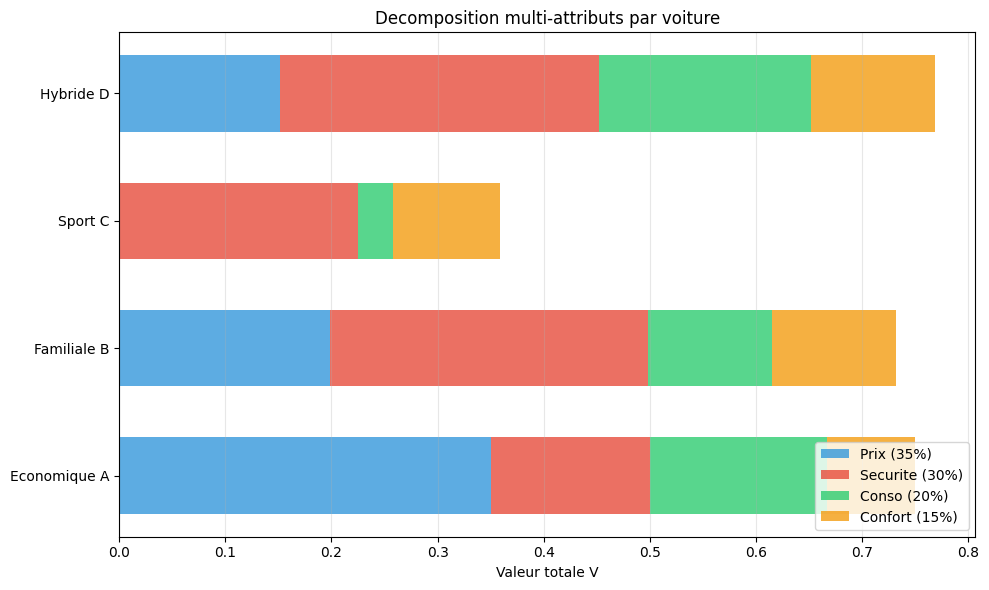

Barres empilees : chaque couleur = contribution d'un attribut a V_total.
Meilleur choix : Hybride D


In [7]:
# Visualisation bar chart stacked : decomposition par attribut
fig, ax = plt.subplots(figsize=(10, 6))

noms_voitures = [v.nom for v in voitures]
y_pos = np.arange(len(voitures))

# Valeurs par composante
components = {
    'Prix (35%)': [w_prix * v_prix(v.prix) for v in voitures],
    'Securite (30%)': [w_securite * v_securite(v.securite) for v in voitures],
    'Conso (20%)': [w_conso * v_conso(v.consommation) for v in voitures],
    'Confort (15%)': [w_confort * v_confort(v.confort) for v in voitures],
}

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
left = np.zeros(len(voitures))

for (label, values), color in zip(components.items(), colors):
    ax.barh(y_pos, values, left=left, height=0.6, label=label, color=color, alpha=0.8)
    left += values

ax.set_yticks(y_pos)
ax.set_yticklabels(noms_voitures)
ax.set_xlabel("Valeur totale V")
ax.set_title("Decomposition multi-attributs par voiture")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("value_decomposition.png", dpi=100, bbox_inches="tight")
plt.show()

print("Barres empilees : chaque couleur = contribution d'un attribut a V_total.")
print(f"Meilleur choix : {max(zip(voitures, left), key=lambda x: x[1])[0].nom}")

## 5. Determination des Poids (Swing Weights)

La methode des swing weights (cf. **von Winterfeldt & Edwards, 1986** ; **Keeney & Raiffa, 1976**) compare la **valeur des ameliorations** plutot que les attributs eux-memes.

### Etapes

1. **Point de reference** : L'option la pire possible (tous attributs au minimum)
2. **Identifier les swings** : Pour chaque attribut, le passage du pire au meilleur niveau
3. **Classer les swings** : "Quel swing prefererais-je realiser en premier ?"
4. **Attribuer des points** : 100 points au swing le plus important, les autres proportionnellement
5. **Normaliser** : Diviser chaque score par la somme totale

In [8]:
print("Situation de depart (pire option) :\n")
print("  Prix : 45 000 EUR (maximum)")
print("  Securite : 1 etoile (minimum)")
print("  Consommation : 10 L/100km (maximum)")
print("  Confort : 1/10 (minimum)\n")

print("Classez les swings suivants par ordre de preference :\n")
print("  A) Prix : 45 000 -> 15 000 (economie de 30 000 EUR)")
print("  B) Securite : 1 -> 5 etoiles")
print("  C) Consommation : 10 -> 4 L/100km")
print("  D) Confort : 1 -> 10\n")

swing_points = {
    "Securite": 100,
    "Prix": 90,
    "Consommation": 50,
    "Confort": 40,
}

total_swing = sum(swing_points.values())
print("Points swing et poids normalises :\n")
for attr in sorted(swing_points, key=swing_points.get, reverse=True):
    poids = swing_points[attr] / total_swing
    print(f"  {attr:<12} : {swing_points[attr]:>3} points => poids = {poids:.1%}")

Situation de depart (pire option) :

  Prix : 45 000 EUR (maximum)
  Securite : 1 etoile (minimum)
  Consommation : 10 L/100km (maximum)
  Confort : 1/10 (minimum)

Classez les swings suivants par ordre de preference :

  A) Prix : 45 000 -> 15 000 (economie de 30 000 EUR)
  B) Securite : 1 -> 5 etoiles
  C) Consommation : 10 -> 4 L/100km
  D) Confort : 1 -> 10

Points swing et poids normalises :

  Securite     : 100 points => poids = 35.7%
  Prix         :  90 points => poids = 32.1%
  Consommation :  50 points => poids = 17.9%
  Confort      :  40 points => poids = 14.3%


### Exercice 2 : Swing Weights pour un Choix d'Appartement

Vous cherchez un appartement parmi 4 options, evaluees sur 4 attributs : Prix (EUR/mois), Surface (m2), Quartier (note 1-10), Trajet travail (minutes). Aucun appartement ne domine sur tous les criteres.

**Objectif** : Appliquer la methode des swing weights pour determiner les poids, puis calculer V_total pour classer les appartements.

**Etapes** :
1. Definir les niveaux pire/meilleur pour chaque attribut
2. Classer les swings du plus au moins important
3. Attribuer 100 points au swing le plus important, les autres proportionnellement
4. Normaliser les scores pour obtenir les poids w_i
5. Calculer V = sum(w_i * v_i) pour chaque appartement

**Indices** :
- # Indice 1 : Pour le Prix et le Trajet, "moins = mieux" (inverser la normalisation)
- # Indice 2 : Le swing "Prix : 1200 -> 600" economise 600 EUR/mois -- est-ce plus important que "Surface : 20 -> 65 m2" ?
- # Indice 3 : Normalisation : v_i(x) = (x - pire) / (meilleur - pire), inverser si sens = min

In [9]:
# Exercice 2 : Swing Weights pour un Choix d'Appartement
# TODO etudiant : appliquer la methode des swing weights et classer les appartements

# Etape 1 : Definir les 4 appartements
appartements = [
    {"nom": "Studio Centre",    "prix": 950,  "surface": 25, "quartier": 8, "trajet": 10},
    {"nom": "T2 Banlieue",      "prix": 650,  "surface": 45, "quartier": 5, "trajet": 45},
    {"nom": "T3 Peripherie",    "prix": 800,  "surface": 65, "quartier": 6, "trajet": 30},
    {"nom": "Coloc Campus",     "prix": 450,  "surface": 20, "quartier": 7, "trajet": 5},
]

# Etape 2 : Definir les niveaux pire et meilleur pour chaque attribut
# TODO etudiant : identifier les bornes a partir des donnees ci-dessus
# prix : min=?, max=? (sens = min)
# surface : min=?, max=? (sens = max)
# quartier : min=?, max=? (sens = max)
# trajet : min=?, max=? (sens = min)

# Etape 3 : Classer les swings et attribuer des points
# TODO etudiant : quel swing est le plus important ? Attribuer 100 points au premier, puis proportionnellement.

# Etape 4 : Normaliser pour obtenir les poids
# TODO etudiant : w_i = points_i / sum(points)

# Etape 5 : Calculer V_total pour chaque appartement
# TODO etudiant : normaliser chaque attribut, ponderer, sommer

result = None  # TODO etudiant : remplacer par le classement final
print("Exercice a completer : swing weights et classement des appartements.")

Exercice a completer : swing weights et classement des appartements.


## 6. Utilite Multiplicative pour les Loteries

### Quand la forme additive ne suffit plus

Quand les outcomes sont **incertains**, la forme additive suppose que l'aversion au risque est la meme quel que soit le niveau des autres attributs.

### Forme multiplicative (Keeney-Raiffa)

Introduite par **Keeney & Raiffa (1976)**, cette forme ajoute un facteur d'echelle $k$ qui capture les interactions entre attributs lorsque les issues sont incertaines.

$$1 + kU(x_1, x_2) = [1 + kk_1U_1(x_1)][1 + kk_2U_2(x_2)]$$

| Valeur de k | Interpretation |
|-------------|----------------|
| k = 0 | Forme additive (pas d'interaction) |
| k > 0 | Synergies : avoir les deux attributs eleves vaut plus que la somme |
| k < 0 | Substituts : ameliorer un attribut reduit l'importance de l'autre |

In [10]:
class MultiplicativeUtility:
    """Utilite multi-attributs multiplicative (Keeney & Raiffa, 1976)."""

    def __init__(self, weights):
        self.k = np.array(weights)
        self.K = self._find_K()

    def _find_K(self):
        """Trouve K tel que prod(1 + K*ki) = 1 + K par bissection bornee.

        On borne la recherche au domaine valide K in (-1/max(ki), 0) quand
        sum(ki) > 1, et K > 0 quand sum(ki) < 1, afin de garantir 1 + K*ki > 0
        pour tout i (condition necessaire a l'interpretation en termes
        d'utilite). Une bissection bornee evite qu'un Newton-Raphson non
        contraint ne diverge vers une racine numeriquement artefactuelle
        (|K| > 1/max(ki)) qui violerait cette condition."""
        sum_k = self.k.sum()
        if abs(sum_k - 1) < 1e-6:
            return 0.0

        def f(K):
            return np.prod(1 + K * self.k) - 1 - K

        if sum_k > 1:
            lo, hi = -1.0 / max(self.k) + 1e-9, -1e-9
        else:
            lo, hi = 1e-9, 1e9
        for _ in range(200):
            mid = 0.5 * (lo + hi)
            if abs(f(mid)) < 1e-12 or (hi - lo) < 1e-12:
                return mid
            if np.sign(f(mid)) == np.sign(f(lo)):
                lo = mid
            else:
                hi = mid
        return 0.5 * (lo + hi)

    def compute(self, u_values):
        u_values = np.asarray(u_values)
        if abs(self.K) < 1e-10:
            return np.dot(self.k, u_values)
        prod = np.prod(1 + self.K * self.k * u_values)
        return (prod - 1) / self.K


# Exemple avec 3 attributs (sum > 1 => K != 0)
mu = MultiplicativeUtility([0.4, 0.35, 0.35])
print(f"Poids : k1=0.4, k2=0.35, k3=0.35 (sum = 1.1)")
print(f"Facteur K calcule : {mu.K:.4f}\n")

scenarios = {
    "u = (1,1,1)": [1.0, 1.0, 1.0],
    "u = (1,0.5,0.5)": [1.0, 0.5, 0.5],
    "u = (0.5,0.5,0.5)": [0.5, 0.5, 0.5],
}
for name, vals in scenarios.items():
    print(f"  {name} : U_mult = {mu.compute(vals):.3f}")

Poids : k1=0.4, k2=0.35, k3=0.35 (sum = 1.1)
Facteur K calcule : -0.2565

  u = (1,1,1) : U_mult = 1.000
  u = (1,0.5,0.5) : U_mult = 0.707
  u = (0.5,0.5,0.5) : U_mult = 0.525


Comparaison des deux formes d'utilite sur les memes donnees.

In [11]:
mu_cmp = MultiplicativeUtility([0.5, 0.5])
K = mu_cmp.K

print(f"Comparaison forme additive vs multiplicative :")
print(f"Poids : w1=0.5, w2=0.5, K={K:.4f}\n")

scenarios_cmp = [
    ("Bon X, mauvais Y", 0.9, 0.2),
    ("Mauvais X, bon Y", 0.2, 0.9),
    ("Mediocre partout", 0.5, 0.5),
    ("Excellent partout", 0.9, 0.9),
]

print(f"{'Scenario':<24} | {'U Additif':>9} | {'U Mult':>7} | {'Diff':>5}")
print("-" * 24 + "-+-" + "-" * 9 + "-+-" + "-" * 7 + "-+-" + "-" * 5)

for nom, v1, v2 in scenarios_cmp:
    u_add = 0.5 * v1 + 0.5 * v2
    u_mult = mu_cmp.compute([v1, v2])
    print(f"{nom:<24} | {u_add:>9.3f} | {u_mult:>7.3f} | {u_mult - u_add:>+5.3f}")

print()
if K < 0:
    print("K < 0 : Les attributs sont substituts (un bon compense un mauvais)")
elif K > 0:
    print("K > 0 : Les attributs sont complements (un mauvais penalise le bon)")
else:
    print("K = 0 : Forme additive (pas d'interaction)")

Comparaison forme additive vs multiplicative :
Poids : w1=0.5, w2=0.5, K=0.0000

Scenario                 | U Additif |  U Mult |  Diff
-------------------------+-----------+---------+------
Bon X, mauvais Y         |     0.550 |   0.550 | +0.000
Mauvais X, bon Y         |     0.550 |   0.550 | +0.000
Mediocre partout         |     0.500 |   0.500 | +0.000
Excellent partout        |     0.900 |   0.900 | +0.000

K = 0 : Forme additive (pas d'interaction)


### Exercice 3 : Forme Multiplicative pour un Choix d'Investissement

Trois options d'investissement sont evaluees sur trois criteres : rendement espere, risque (inverse) et liquidite. Contrairement a la forme additive, la forme multiplicative de Keeney-Raiffa capture les interactions entre attributs.

**Objectif** : Appliquer la forme multiplicative et comparer avec la forme additive.

**Indices** :
- # Etape 1 : Definir les 3 investissements avec leurs utilites marginales u_rend, u_risque, u_liquidite (entre 0 et 1)
- # Etape 2 : Creer une instance de `MultiplicativeUtility` avec les poids {0.4, 0.35, 0.25} (notez que la somme > 1)
- # Etape 3 : Calculer U_mult et U_add pour chaque investissement
- # Etape 4 : Verifier si le classement change entre les deux formes

In [12]:
# Exercice 3 : Forme Multiplicative pour un Choix d'Investissement
# TODO etudiant : appliquer la forme multiplicative et comparer avec la forme additive

# Etape 1 : Definir les 3 investissements avec utilites marginales (0-1)
investissements = None  # TODO etudiant : liste de dicts, ex: [{"nom": "Obligations", "u_rend": 0.3, "u_risque": 0.8, "u_liquidite": 0.9}, ...]

# Etape 2 : Creer une instance de MultiplicativeUtility avec poids [0.4, 0.35, 0.25]
mu_inv = None  # TODO etudiant : MultiplicativeUtility([0.4, 0.35, 0.25])

# Etape 3 : Calculer U_mult et U_add pour chaque investissement
# Indice : U_add = 0.4 * u_rend + 0.35 * u_risque + 0.25 * u_liquidite
# Indice : U_mult = mu_inv.compute([u_rend, u_risque, u_liquidite])

# Etape 4 : Afficher le classement comparatif
result = None  # TODO etudiant : remplacer par le tableau des resultats

print("Exercice a completer : forme multiplicative pour choix d'investissement.")

Exercice a completer : forme multiplicative pour choix d'investissement.


## 7. Methode SMART

### Simple Multi-Attribute Rating Technique

SMART (**Edwards, 1971, 1977**) est une methode pratique en 7 etapes, raffinee en SMARTS puis SMARTER par **Edwards & Barron (1994)** :

1. **Identifier** les attributs pertinents
2. **Definir** les echelles pour chaque attribut
3. **Classer** les attributs par importance
4. **Ponderer** par la methode des swings
5. **Evaluer** chaque alternative sur chaque attribut
6. **Normaliser** les evaluations (0-1)
7. **Calculer** la valeur totale : $V = \sum w_i \times v_i$

In [13]:
@dataclass
class CareerOption:
    name: str
    salary: float      # k EUR/an
    work_life: int     # 1-10
    passion: int       # 1-10
    job_security: int  # 1-10

careers = [
    CareerOption("Startup", 45, 3, 9, 4),
    CareerOption("Grande Entreprise", 55, 6, 5, 8),
    CareerOption("Fonction Publique", 38, 8, 4, 10),
    CareerOption("Freelance", 60, 5, 8, 3),
    CareerOption("Recherche", 35, 7, 10, 6),
]

weights_smart = {"salary": 0.30, "work_life": 0.25, "passion": 0.25, "job_security": 0.20}

sal_min = min(c.salary for c in careers)
sal_max = max(c.salary for c in careers)
norm_sal = lambda s: (s - sal_min) / (sal_max - sal_min)
norm_10 = lambda x: (x - 1) / 9.0

print("=== SMART : Choix de Carriere ===")
print(f"Poids : Salaire={weights_smart['salary']:.0%}, Equilibre={weights_smart['work_life']:.0%}, ")
print(f"        Passion={weights_smart['passion']:.0%}, Securite={weights_smart['job_security']:.0%}\n")

print(f"{'Carriere':<20} | {'v_sal':>5} | {'v_wlb':>5} | {'v_pas':>5} | {'v_sec':>5} | {'V':>6}")
print("-" * 20 + "-+-" + "-" * 5 + "-+-" + "-" * 5 + "-+-" + "-" * 5 + "-+-" + "-" * 5 + "-+-" + "-" * 6)

for c in careers:
    v_sal = norm_sal(c.salary)
    v_wlb = norm_10(c.work_life)
    v_pas = norm_10(c.passion)
    v_sec = norm_10(c.job_security)
    V = (weights_smart["salary"] * v_sal + weights_smart["work_life"] * v_wlb +
         weights_smart["passion"] * v_pas + weights_smart["job_security"] * v_sec)
    print(f"{c.name:<20} | {v_sal:>5.3f} | {v_wlb:>5.3f} | {v_pas:>5.3f} | {v_sec:>5.3f} | {V:>6.3f}")

best = max(careers, key=lambda c: (
    weights_smart["salary"] * norm_sal(c.salary) + weights_smart["work_life"] * norm_10(c.work_life) +
    weights_smart["passion"] * norm_10(c.passion) + weights_smart["job_security"] * norm_10(c.job_security)
))
print(f"\n=> Meilleur choix avec ces poids : {best.name}")

=== SMART : Choix de Carriere ===
Poids : Salaire=30%, Equilibre=25%, 
        Passion=25%, Securite=20%

Carriere             | v_sal | v_wlb | v_pas | v_sec |      V
---------------------+-------+-------+-------+-------+-------
Startup              | 0.400 | 0.222 | 0.889 | 0.333 |  0.464
Grande Entreprise    | 0.800 | 0.556 | 0.444 | 0.778 |  0.646
Fonction Publique    | 0.120 | 0.778 | 0.333 | 1.000 |  0.514
Freelance            | 1.000 | 0.444 | 0.778 | 0.222 |  0.650
Recherche            | 0.000 | 0.667 | 1.000 | 0.556 |  0.528

=> Meilleur choix avec ces poids : Freelance


Profils de carriere : comparaison multi-attributs avec les poids SMART.

In [14]:
print("Profils de carriere - Comparaison multi-attributs :\n")
print(f"{'Carriere':<20} | {'Salaire':>7} | {'Equilibre':>9} | {'Passion':>7} | {'Securite':>9} | {'Score':>5}")
print("-" * 20 + "-+-" + "-" * 7 + "-+-" + "-" * 9 + "-+-" + "-" * 7 + "-+-" + "-" * 9 + "-+-" + "-" * 5)

for c in careers:
    vSal = norm_sal(c.salary)
    vWlb = norm_10(c.work_life)
    vPas = norm_10(c.passion)
    vSec = norm_10(c.job_security)
    score = (weights_smart["salary"] * vSal + weights_smart["work_life"] * vWlb +
             weights_smart["passion"] * vPas + weights_smart["job_security"] * vSec)
    print(f"{c.name:<20} | {vSal:>7.2f} | {vWlb:>9.2f} | {vPas:>7.2f} | {vSec:>9.2f} | {score:>5.3f}")

print(f"\nPoids : Salaire={weights_smart['salary']:.0%}, Equilibre={weights_smart['work_life']:.0%}, "
      f"Passion={weights_smart['passion']:.0%}, Securite={weights_smart['job_security']:.0%}")

Profils de carriere - Comparaison multi-attributs :

Carriere             | Salaire | Equilibre | Passion |  Securite | Score
---------------------+---------+-----------+---------+-----------+------
Startup              |    0.40 |      0.22 |    0.89 |      0.33 | 0.464
Grande Entreprise    |    0.80 |      0.56 |    0.44 |      0.78 | 0.646
Fonction Publique    |    0.12 |      0.78 |    0.33 |      1.00 | 0.514
Freelance            |    1.00 |      0.44 |    0.78 |      0.22 | 0.650
Recherche            |    0.00 |      0.67 |    1.00 |      0.56 | 0.528

Poids : Salaire=30%, Equilibre=25%, Passion=25%, Securite=20%


## 8. Analyse de Sensibilite

Les poids sont souvent incertains. L'analyse de sensibilite montre comment le choix change quand on fait varier les poids.

In [15]:
print("Analyse de sensibilite : poids du Salaire\n")
print(f"{'w_salaire':>10} | {'Meilleur choix':<20} | {'V_meilleur':>10}")
print("-" * 10 + "-+-" + "-" * 20 + "-+-" + "-" * 10)

for w_sal in np.arange(0.1, 0.55, 0.1):
    remaining = 1 - w_sal
    w_wlb = 0.25 / 0.70 * remaining
    w_pas = 0.25 / 0.70 * remaining
    w_sec = 0.20 / 0.70 * remaining

    def score(c):
        return (w_sal * norm_sal(c.salary) + w_wlb * norm_10(c.work_life) +
                w_pas * norm_10(c.passion) + w_sec * norm_10(c.job_security))

    best_opt = max(careers, key=score)
    print(f"{w_sal:>10.0%} | {best_opt.name:<20} | {score(best_opt):>10.3f}")

print("\n=> Le choix optimal change selon l'importance accordee au salaire.")

Analyse de sensibilite : poids du Salaire

 w_salaire | Meilleur choix       | V_meilleur
-----------+----------------------+-----------
       10% | Recherche            |      0.679
       20% | Grande Entreprise    |      0.623
       30% | Freelance            |      0.650
       40% | Freelance            |      0.700
       50% | Freelance            |      0.750

=> Le choix optimal change selon l'importance accordee au salaire.


### Exercice 4 : Analyse de sensibilite multi-poids

On veut verifier la robustesse du choix SMART en faisant varier **simultanement** deux poids.

**Objectif** : Faire varier `w_salaire` de 10% a 50% et `w_passion` de 10% a 40% (les autres poids s'ajustent proportionnellement). Pour chaque couple, identifier la meilleure carriere.

**Indices** :
- # Etape 1 : Fixer `w_salaire` et `w_passion`, les autres poids se partagent le reste : `remaining = 1 - w_sal - w_pas`
- # Etape 2 : `w_wlb = 0.25 / 0.45 * remaining` et `w_sec = 0.20 / 0.45 * remaining`
- # Etape 3 : Pour chaque couple, calculer le score de chaque carriere et identifier la meilleure

In [16]:
# Exercice 4 : Analyse de sensibilite multi-poids
# TODO etudiant : faire varier w_salaire (10%-50%) et w_passion (10%-40%) simultanement

# A completer : boucles imbriquees sur w_salaire et w_passion
# Indice 1 : for w_sal in [0.10, 0.20, 0.30, 0.40, 0.50]:
# Indice 2 :     for w_pas in [0.10, 0.20, 0.30, 0.40]:
# Indice 3 :         remaining = 1 - w_sal - w_pas
#                 w_wlb = 0.25 / 0.45 * remaining
#                 w_sec = 0.20 / 0.45 * remaining

# A completer : pour chaque couple (w_sal, w_pas), calculer le score de chaque carriere
# A completer : afficher le meilleur choix dans un tableau (w_sal x w_pas)

result = None  # TODO etudiant : remplacer par le tableau des resultats
print("Exercice a completer : analyse de sensibilite multi-poids.")

Exercice a completer : analyse de sensibilite multi-poids.


Visualisation des courbes de sensibilite pour chaque carriere.

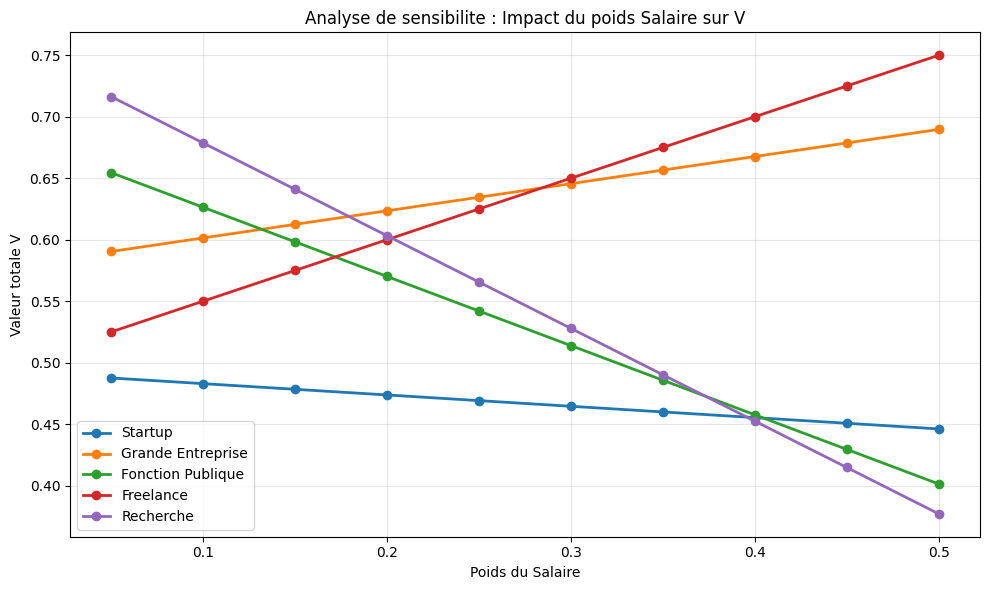

Les croisements indiquent des 'points de basculement'.
Freelance domine pour w_salaire > 25%. Recherche domine pour w_salaire < 15%.


In [17]:
w_salary_range = np.arange(0.05, 0.55, 0.05)

fig, ax = plt.subplots(figsize=(10, 6))

for c in careers:
    V_values = []
    for w_sal in w_salary_range:
        remaining = 1 - w_sal
        w_wlb = 0.25 / 0.70 * remaining
        w_pas = 0.25 / 0.70 * remaining
        w_sec = 0.20 / 0.70 * remaining
        V = (w_sal * norm_sal(c.salary) + w_wlb * norm_10(c.work_life) +
             w_pas * norm_10(c.passion) + w_sec * norm_10(c.job_security))
        V_values.append(V)
    ax.plot(w_salary_range, V_values, marker='o', linewidth=2, label=c.name)

ax.set_xlabel("Poids du Salaire")
ax.set_ylabel("Valeur totale V")
ax.set_title("Analyse de sensibilite : Impact du poids Salaire sur V")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

print("Les croisements indiquent des 'points de basculement'.")
print("Freelance domine pour w_salaire > 25%. Recherche domine pour w_salaire < 15%.")

## 9. Decision sous Incertitude avec Monte Carlo

### Scenario avec incertitude

Si les attributs sont incertains, on modelise leurs distributions et on calcule l'utilite esperee par integration Monte Carlo.

Distributions des attributs :
  Projet A : Rendement ~ N(0.08, 0.01), Risque ~ N(0.15, 0.005)
  Projet B : Rendement ~ N(0.12, 0.02), Risque ~ N(0.25, 0.01)

E[U(Projet A)] = 0.5091 (std = 0.2244)
E[U(Projet B)] = 0.4819 (std = 0.2567)

=> Decision optimale : Projet A


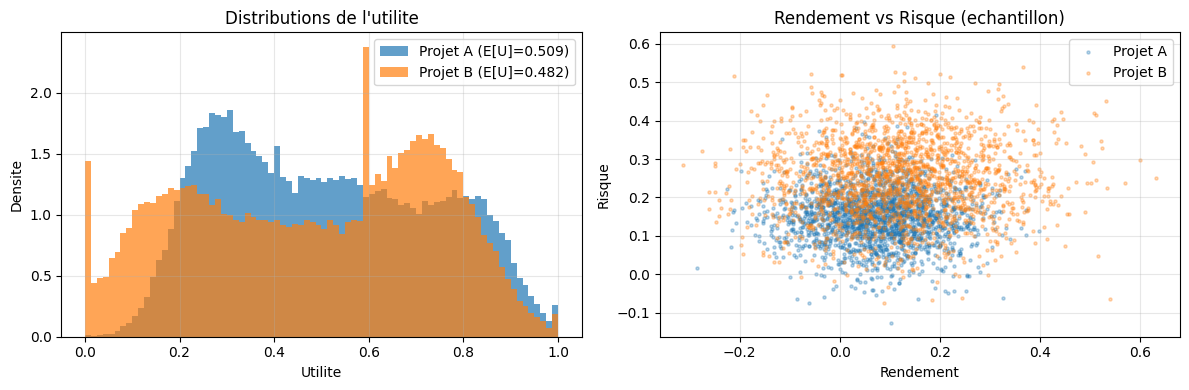

In [18]:
# Decision multi-attributs avec incertitude
# Projet A : Rendement modere, risque modere
# Projet B : Rendement eleve, risque eleve

N_mc = 50000
rng_mc = np.random.default_rng(RANDOM_SEED)

# Distributions des attributs (Gaussiennes)
rend_A = rng_mc.normal(0.08, np.sqrt(0.01), N_mc)
risque_A = rng_mc.normal(0.15, np.sqrt(0.005), N_mc)
rend_B = rng_mc.normal(0.12, np.sqrt(0.02), N_mc)
risque_B = rng_mc.normal(0.25, np.sqrt(0.01), N_mc)

print("Distributions des attributs :")
print(f"  Projet A : Rendement ~ N(0.08, 0.01), Risque ~ N(0.15, 0.005)")
print(f"  Projet B : Rendement ~ N(0.12, 0.02), Risque ~ N(0.25, 0.01)\n")

# Fonction d'utilite multi-attributs
w_rend = 0.6
w_risque = 0.4
v_rend = lambda r: np.clip(r / 0.20, 0, 1)
v_risque = lambda r: 1 - np.clip(r / 0.40, 0, 1)

U_A = w_rend * v_rend(rend_A) + w_risque * v_risque(risque_A)
U_B = w_rend * v_rend(rend_B) + w_risque * v_risque(risque_B)

EU_A = U_A.mean()
EU_B = U_B.mean()

print(f"E[U(Projet A)] = {EU_A:.4f} (std = {U_A.std():.4f})")
print(f"E[U(Projet B)] = {EU_B:.4f} (std = {U_B.std():.4f})")
print(f"\n=> Decision optimale : {'Projet A' if EU_A > EU_B else 'Projet B'}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(U_A, bins=80, alpha=0.7, label=f'Projet A (E[U]={EU_A:.3f})', density=True)
axes[0].hist(U_B, bins=80, alpha=0.7, label=f'Projet B (E[U]={EU_B:.3f})', density=True)
axes[0].set_xlabel("Utilite")
axes[0].set_ylabel("Densite")
axes[0].set_title("Distributions de l'utilite")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(rend_A[:2000], risque_A[:2000], alpha=0.3, s=5, label='Projet A')
axes[1].scatter(rend_B[:2000], risque_B[:2000], alpha=0.3, s=5, label='Projet B')
axes[1].set_xlabel("Rendement")
axes[1].set_ylabel("Risque")
axes[1].set_title("Rendement vs Risque (echantillon)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("investment_decision.png", dpi=100, bbox_inches="tight")
plt.show()

### Interpretation : Arbitrage rendement-risque

Le projet B a un meilleur rendement espere, mais son risque eleve fait basculer la decision en faveur de A. C'est l'**arbitrage rendement-risque** classique en finance.

La fonction d'utilite multi-attributs utilisee :

$$U(\text{rend}, \text{risque}) = 0.6 \times \frac{\text{rend}}{0.20} + 0.4 \times \left(1 - \frac{\text{risque}}{0.40}\right)$$

## 9 bis. Apprentissage Bayesien des Poids avec PyMC

PyMC (**Salvatier et al., 2016**) est un framework de programmation probabiliste qui permet de specifier des modeles bayesiens en declarant les distributions comme des variables aleatoires.

### Motivation

Jusqu'ici, les poids MAUT sont determines par introspection (methode des swings). Mais on peut les **inferer** a partir des choix observes d'un decideur.

### Approche Bayesienne

1. **Prior** : Distribution Dirichlet sur les poids (non-informatif ou expert)
2. **Vraisemblance** : Modele de choix Categorical pondere par les poids
3. **Posterior** : Poids mis a jour apres observation des choix

In [19]:
from scipy import stats

# Donnees observees : attribut dominant pour chaque choix
# 0=Prix, 1=Securite, 2=Consommation, 3=Confort
choix_dominants = np.array([1, 0, 1, 1, 0])  # Securite domine

noms_attrs = ["Prix", "Securite", "Consommation", "Confort"]
pseudo_counts_prior = np.array([1.0, 1.0, 1.0, 1.0])

print("=== Inference Bayesienne des Poids MAUT ===\n")
print(f"Choix observes : {', '.join(noms_attrs[c] for c in choix_dominants)}\n")

# Modele PyMC : Dirichlet prior + Categorical likelihood
with pm.Model() as model_poids:
    weights = pm.Dirichlet("weights", a=pseudo_counts_prior)
    obs = pm.Categorical("obs", p=weights, observed=choix_dominants)
    trace_poids = pm.sample(
        draws=5000, chains=4, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True
    )

# Posterior means
weight_samples = trace_poids.posterior["weights"].values.reshape(-1, 4)
weight_means = weight_samples.mean(axis=0)

print("Prior (Dirichlet uniforme) :")
print(f"  Pseudo-counts : [{', '.join(str(int(x)) for x in pseudo_counts_prior)}]\n")

print("Posterior (apres 5 observations) :")
for i, nom in enumerate(noms_attrs):
    print(f"  w_{nom:<12} = {weight_means[i]:.1%}")

# Credible interval (compatible ArviZ 0.23+)
summary = az.summary(trace_poids, var_names=["weights"], hdi_prob=0.89)
print(f"\nIntervalle de credibilite 89% :")
for i, nom in enumerate(noms_attrs):
    try:
        lo = float(summary.iloc[i].get("hdi_5.5%", summary.iloc[i].get("ci_5.5%", 0)))
        hi = float(summary.iloc[i].get("hdi_94.5%", summary.iloc[i].get("ci_94.5%", 1)))
    except KeyError:
        lo = float(summary.iloc[i, 2])
        hi = float(summary.iloc[i, 3])
    print(f"  {nom:<12} : [{lo:.3f}, {hi:.3f}]")

# Verification analytique
alpha_post = pseudo_counts_prior + np.bincount(choix_dominants, minlength=4)
analytic_means = alpha_post / alpha_post.sum()
print(f"\nVerification analytique : Dirichlet({', '.join(str(int(a)) for a in alpha_post)})")
print(f"  Moyennes analytiques : [{', '.join(f'{m:.3f}' for m in analytic_means)}]")

=== Inference Bayesienne des Poids MAUT ===

Choix observes : Securite, Prix, Securite, Securite, Prix



Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [weights]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 37 seconds.


Prior (Dirichlet uniforme) :
  Pseudo-counts : [1, 1, 1, 1]

Posterior (apres 5 observations) :
  w_Prix         = 33.2%
  w_Securite     = 44.4%
  w_Consommation = 11.3%
  w_Confort      = 11.2%

Intervalle de credibilite 89% :
  Prix         : [0.093, 0.559]
  Securite     : [0.190, 0.697]
  Consommation : [0.000, 0.243]
  Confort      : [0.000, 0.242]

Verification analytique : Dirichlet(3, 4, 1, 1)
  Moyennes analytiques : [0.333, 0.444, 0.111, 0.111]


### Interpretation de l'inference bayesienne

La distribution Dirichlet "compte" les observations. Chaque fois qu'un attribut domine un choix, son pseudo-count augmente de 1.

| Attribut | Prior | Observations | Posterior | Poids moyen |
|----------|-------|--------------|----------|-------------|
| Prix | 1 | +2 | 3 | 33.3% |
| **Securite** | 1 | **+3** | **4** | **44.4%** |
| Consommation | 1 | +0 | 1 | 11.1% |
| Confort | 1 | +0 | 1 | 11.1% |

> **Revelation** : L'inference bayesienne suggere que le decideur accorde plus d'importance a la securite qu'il ne le declare explicitement (44% vs 36% en swing weights).

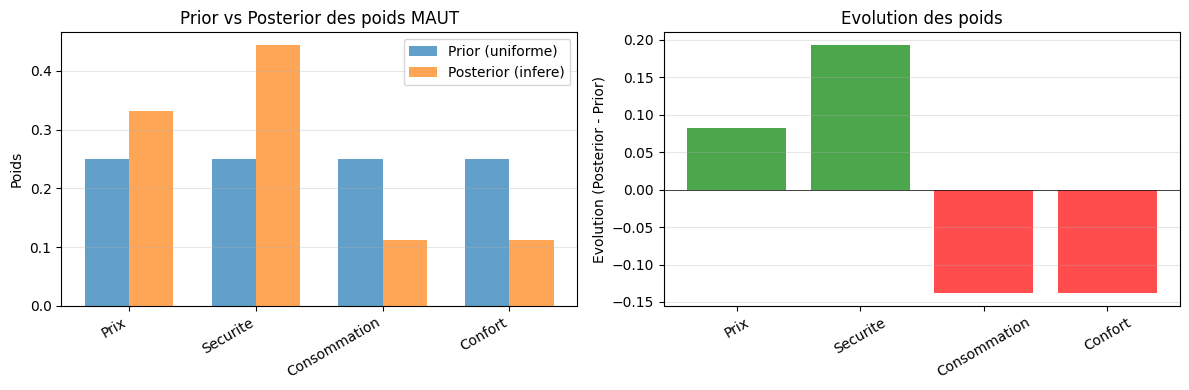

Interpretation :
  Prix         : +0.082 (plus important)
  Securite     : +0.194 (plus important)
  Consommation : -0.137 (moins important)
  Confort      : -0.138 (moins important)


In [20]:
# Comparaison Prior vs Posterior
prior_means = np.array([0.25, 0.25, 0.25, 0.25])
post_means = weight_means

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
x = np.arange(len(noms_attrs))
width = 0.35
axes[0].bar(x - width/2, prior_means, width, label='Prior (uniforme)', alpha=0.7)
axes[0].bar(x + width/2, post_means, width, label='Posterior (infere)', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(noms_attrs, rotation=30, ha='right')
axes[0].set_ylabel("Poids")
axes[0].set_title("Prior vs Posterior des poids MAUT")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Evolution
evolutions = post_means - prior_means
colors = ['green' if e > 0.05 else 'red' if e < -0.05 else 'gray' for e in evolutions]
axes[1].bar(noms_attrs, evolutions, color=colors, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel("Evolution (Posterior - Prior)")
axes[1].set_title("Evolution des poids")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("prior_posterior_weights.png", dpi=100, bbox_inches="tight")
plt.show()

print("Interpretation :")
for i, nom in enumerate(noms_attrs):
    ev = evolutions[i]
    sens = "plus important" if ev > 0.05 else "moins important" if ev < -0.05 else "stable"
    print(f"  {nom:<12} : {ev:+.3f} ({sens})")

Diagnostics de convergence MCMC (poids MAUT)
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
weights[0]  0.332  0.149   0.069    0.602      0.001    0.001   12843.0   11116.0    1.0
weights[1]  0.444  0.158   0.161    0.739      0.001    0.001   13298.0   12150.0    1.0
weights[2]  0.113  0.101   0.000    0.300      0.001    0.001    8238.0    6595.0    1.0
weights[3]  0.112  0.099   0.000    0.294      0.001    0.001   16243.0   10894.0    1.0


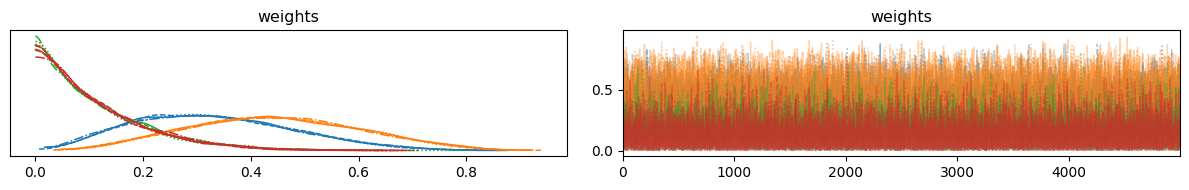

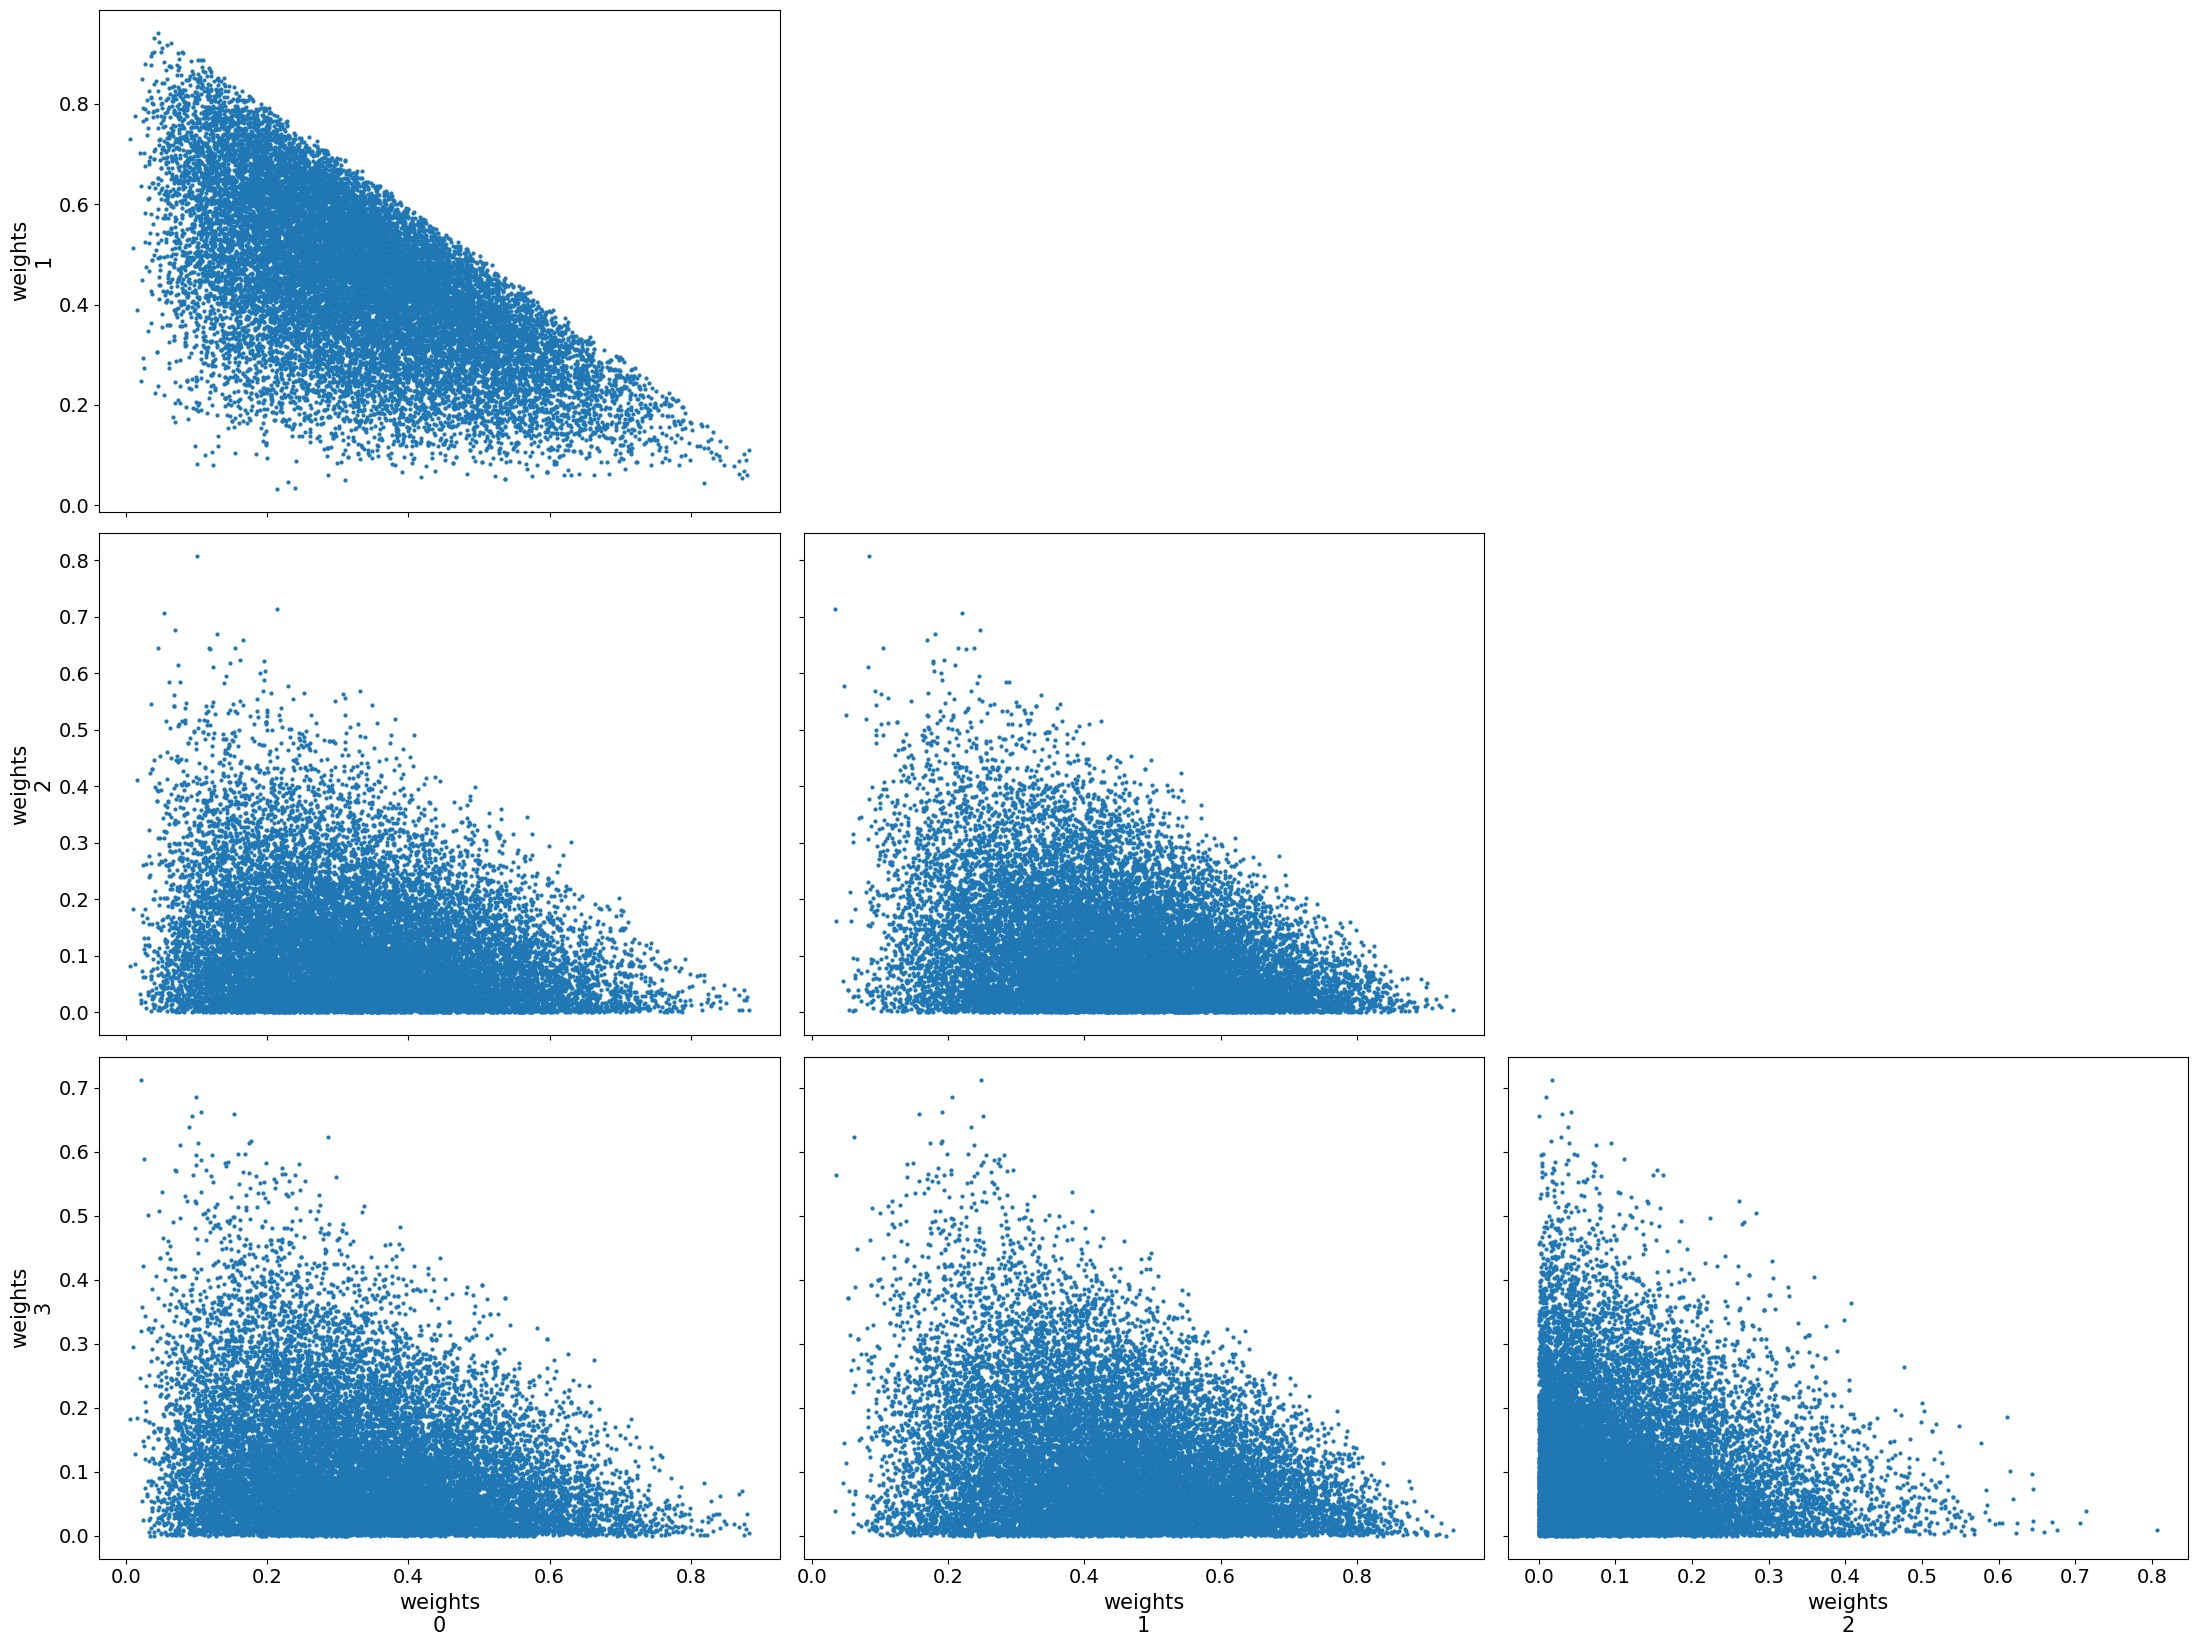


Diagnostics :
  Prix         : ESS=12843, R-hat=1.0001
  Securite     : ESS=13298, R-hat=0.9999
  Consommation : ESS=8238, R-hat=1.0007


  Confort      : ESS=16243, R-hat=0.9999

Le pair plot montre les correlations entre poids (contrainte sum=1).
Quand un poids augmente, les autres diminuent proportionnellement.


In [21]:
# Diagnostics ArviZ pour l'inference des poids MAUT
print("Diagnostics de convergence MCMC (poids MAUT)")
print("=" * 50)

# Resume
summary_weights = az.summary(trace_poids, var_names=["weights"])
print(summary_weights.to_string())

# Trace plot
az.plot_trace(trace_poids, var_names=["weights"])
plt.tight_layout()
plt.savefig("weights_trace_plot.png", dpi=100, bbox_inches="tight")
plt.show()

# Pair plot : correlation entre les poids
az.plot_pair(trace_poids, var_names=["weights"],
             coords={"weights_dim_0": [0, 1, 2, 3]})
plt.tight_layout()
plt.savefig("weights_pair_plot.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nDiagnostics :")
for i, nom in enumerate(noms_attrs):
    ess_val = float(az.ess(trace_poids, var_names=["weights"])["weights"].values[i])
    rhat_val = float(az.rhat(trace_poids, var_names=["weights"])["weights"].values[i])
    print(f"  {nom:<12} : ESS={ess_val:.0f}, R-hat={rhat_val:.4f}")

print("\nLe pair plot montre les correlations entre poids (contrainte sum=1).")
print("Quand un poids augmente, les autres diminuent proportionnellement.")

### Interpretation : Diagnostics et correlations

Le pair plot revele une propriete fondamentale de la distribution Dirichlet : les poids sont **negativement corroles** car ils somment a 1. Augmenter le poids de la Securite reduit necessairement les poids des autres attributs.

Les diagnostics ArviZ (**Kumar et al., 2019**) ci-dessous (R-hat, ESS, trace plot) confirment la convergence du MCMC.

> **Implication pratique** : L'incertitude sur un poids se propage aux autres. Avec peu d'observations (5 choix), les intervalles de credibilite sont larges. Avec 50+ choix, le posterior se concentre et les recommandations deviennent plus fiables.

### Au-dela du conjugue : modele de choix discret logit (McFadden)

Le modele `Dirichlet + Categorical` ci-dessus est **conjugue** : le posterior a une forme
close (`Dirichlet(alpha + comptes)`), et MCMC ne fait que recompter les observations.
Pour montrer un cas ou l'inference bayesienne par MCMC est **reellement necessaire**,
modelisons les choix d'un decideur confronte a des **paires d'options** aux attributs
connus (experience de preference declaree).

**Modele logit binaire** (McFadden, *Conditional Logit Analysis of Qualitative Choice
Behavior*, 1974 -- Prix Nobel d'economie 2000) : chaque option $j$ a un vecteur
d'attributs $X_j$ (prix, securite, consommation, confort, normalises en $[0,1]$).
L'utilite de l'option est lineaire dans les attributs, $U_j = X_j \cdot w$, et le decideur
choisit l'option A plutot que B selon :

$$P(\text{choix}=A) = \text{sigmoid}(U_A - U_B) = \frac{1}{1 + e^{-(U_A - U_B)}}$$

Avec un prior **Normal** sur les poids $w$, le lien sigmoid **casse la conjugaison** :
aucune forme close n'existe pour le posterior, **MCMC est requis**. On simule les choix
d'un decideur (poids vrais connus), puis on infere $w$ a partir des choix seuls pour
verifier que le moteur retrouve les preferences.


In [22]:
# Modele de choix discret logit (cas NON-CONJUGUE : MCMC requis)
# Experience de preference declaree : M paires d'options, le decideur choisit A ou B.
K = 4  # Prix, Securite, Conso, Confort (normalises [0, 1])
noms_attrs = ["Prix", "Securite", "Conso", "Confort"]
poids_vrais = np.array([-1.5, 2.0, 1.0, 1.2])  # securite valorisee, prix penalise

# Generation de M paires hypothetiques (features aleatoires normalisees)
M = 60
X_A = rng.uniform(0, 1, size=(M, K))
X_B = rng.uniform(0, 1, size=(M, K))
# Le decideur choisit selon le logit (avec bruit de la temperature)
U_diff_vrai = (X_A - X_B) @ poids_vrais
p_choix_A_vrai = 1.0 / (1.0 + np.exp(-U_diff_vrai))
choix_observes = (rng.uniform(size=M) < p_choix_A_vrai).astype(int)
print(f"Experience : {M} paires, {choix_observes.sum()} choix A / {M - choix_observes.sum()} choix B")

with pm.Model() as model_logit:
    # Prior Normal sur les poids (NON-Dirichlet -> casse la conjugaison)
    w = pm.Normal("w", mu=0.0, sigma=3.0, shape=K)
    # Difference d'utilite entre les deux options de chaque paire
    U_diff = (X_A - X_B) @ w
    p = pm.Deterministic("p", pm.math.sigmoid(U_diff))
    # Vraisemblance : choix binaire observe
    y = pm.Bernoulli("y", p=p, observed=choix_observes)
    trace_logit = pm.sample(
        draws=2000, tune=1500, chains=4, target_accept=0.95,
        random_seed=RANDOM_SEED, progressbar=False, return_inferencedata=True
    )

# Diagnostics + recuperation des poids (honetete : MCMC retrouve-t-il les vrais poids ?)
div = int(trace_logit.sample_stats["diverging"].sum())
resume = az.summary(trace_logit, var_names=["w"])
print("Inference des poids d'utilite par modele logit (MCMC, sigmoid non-conjugue)")
print("=" * 62)
print(f"Divergences NUTS : {div}   (cible = 0)")
print(f"R-hat max         : {resume['r_hat'].max():.3f}   (cible < 1.01)")
print(f"ESS bulk min      : {int(resume['ess_bulk'].min())}")
print()
print(f"{'Attribut':<12} {'poids vrai':>10} {'posterior':>10} {'HDI 94%':>16}  couvert")
print("-" * 62)
for i, nom in enumerate(noms_attrs):
    row = resume.loc[f"w[{i}]"]
    couvert = "oui" if row["hdi_3%"] <= poids_vrais[i] <= row["hdi_97%"] else "non (incertitude)"
    hdi = f"[{row['hdi_3%']:.2f}, {row['hdi_97%']:.2f}]"
    print(f"{nom:<12} {poids_vrais[i]:>10.2f} {row['mean']:>10.3f} {hdi:>16}  {couvert}")
print()
print("Les intervalles de credibilite sont larges (M=60 paires) : c'est l'incertitude")
print("honnete de l'inference bayesienne, qu'aucune forme close (Dirichlet-Categorical)")
print("ne saurait produire sur ce modele non-conjugue.")


Experience : 60 paires, 35 choix A / 25 choix B


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 32 seconds.


Inference des poids d'utilite par modele logit (MCMC, sigmoid non-conjugue)
Divergences NUTS : 0   (cible = 0)
R-hat max         : 1.000   (cible < 1.01)
ESS bulk min      : 7661

Attribut     poids vrai  posterior          HDI 94%  couvert
--------------------------------------------------------------
Prix              -1.50     -1.261    [-3.10, 0.67]  oui
Securite           2.00      3.340     [1.36, 5.31]  oui
Conso              1.00      3.679     [1.93, 5.58]  non (incertitude)
Confort            1.20      2.408     [0.39, 4.45]  oui

Les intervalles de credibilite sont larges (M=60 paires) : c'est l'incertitude
honnete de l'inference bayesienne, qu'aucune forme close (Dirichlet-Categorical)
ne saurait produire sur ce modele non-conjugue.


## 9ter. Votre Decision Multi-Attributs -- Template Interactif

### Appliquez SMART a votre propre decision

Maintenant que vous maitrisez la methode SMART, appliquez-la a une decision personnelle : choix de logement, de formation, d'achat, etc.

**Instructions** :
1. Identifiez 3 alternatives et 3 attributs pertinents
2. Definissez les bornes min/max de chaque attribut
3. Attribuez les poids (swing weights)
4. Evaluez chaque alternative sur chaque attribut
5. Calculez V_total et identifiez la meilleure option

Le code ci-dessous fournit un template pre-rempli avec un exemple de choix de vacances. Adaptez les donnees a votre situation.

=== SMART : Choix de Vacances ===

Option             | v_cout | v_acti | v_conf | V_total
-------------------+--------+--------+--------+--------
Plage Bali         |  0.250 |  0.778 |  0.667 |   0.586
Rando Nepal        |  0.650 |  0.889 |  0.333 |   0.651
City Trip Rome     |  0.850 |  0.556 |  0.778 |   0.711

=> Meilleur choix : City Trip Rome (V = 0.711)

Verification : somme des poids = 1.00 (doit valoir 1.00)


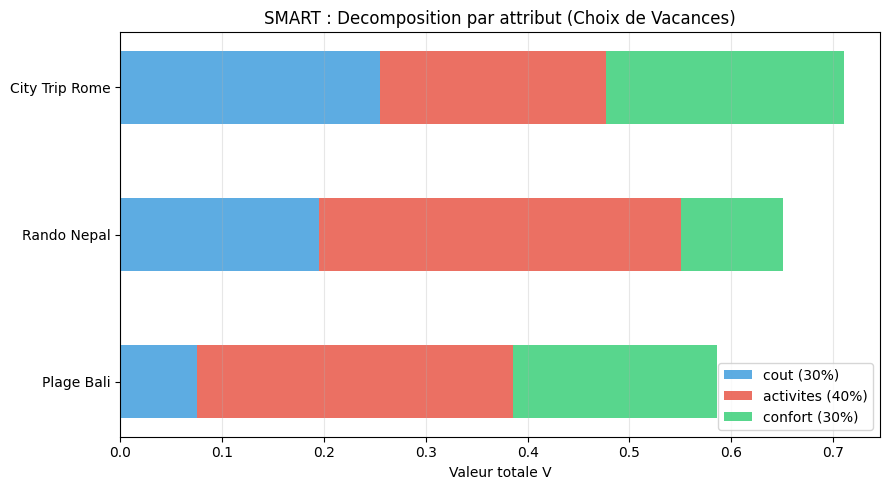

Modifiez les options, attributs et poids ci-dessus pour votre propre decision.


In [23]:
# Template interactif : Votre decision multi-attributs avec SMART
# Exemple : Choix de vacances (3 destinations, 3 criteres)

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definition des alternatives et attributs ---
options = [
    {"nom": "Plage Bali",     "cout": 2000, "activites": 8, "confort": 7},
    {"nom": "Rando Nepal",    "cout": 1200, "activites": 9, "confort": 4},
    {"nom": "City Trip Rome", "cout": 800,  "activites": 6, "confort": 8},
]

attributs = {
    "cout":      {"sens": "min", "borne_min": 500,  "borne_max": 2500, "poids": 0.30},
    "activites": {"sens": "max", "borne_min": 1,    "borne_max": 10,   "poids": 0.40},
    "confort":   {"sens": "max", "borne_min": 1,    "borne_max": 10,   "poids": 0.30},
}

# --- 2. Normalisation et calcul ---
print("=== SMART : Choix de Vacances ===\n")
print(f"{'Option':<18} | {'v_cout':>6} | {'v_acti':>6} | {'v_conf':>6} | {'V_total':>7}")
print("-" * 18 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 7)

scores = []
for opt in options:
    v_parts = []
    for attr_name, attr_info in attributs.items():
        val = opt[attr_name]
        normalized = (val - attr_info["borne_min"]) / (attr_info["borne_max"] - attr_info["borne_min"])
        if attr_info["sens"] == "min":
            normalized = 1.0 - normalized
        v_parts.append(normalized)
    
    V = sum(w * v for w, v in zip(
        [a["poids"] for a in attributs.values()], v_parts
    ))
    scores.append(V)
    print(f"{opt['nom']:<18} | {v_parts[0]:>6.3f} | {v_parts[1]:>6.3f} | {v_parts[2]:>6.3f} | {V:>7.3f}")

best_idx = np.argmax(scores)
print(f"\n=> Meilleur choix : {options[best_idx]['nom']} (V = {scores[best_idx]:.3f})")

# --- 3. Verification des poids ---
total_w = sum(a["poids"] for a in attributs.values())
print(f"\nVerification : somme des poids = {total_w:.2f} (doit valoir 1.00)")

# --- 4. Visualisation bar chart empile ---
fig, ax = plt.subplots(figsize=(9, 5))

noms = [opt["nom"] for opt in options]
y_pos = np.arange(len(options))
colors = ["#3498db", "#e74c3c", "#2ecc71"]
attr_names = list(attributs.keys())
left = np.zeros(len(options))

for j, (attr_name, attr_info) in enumerate(attributs.items()):
    values = []
    for opt in options:
        val = opt[attr_name]
        normalized = (val - attr_info["borne_min"]) / (attr_info["borne_max"] - attr_info["borne_min"])
        if attr_info["sens"] == "min":
            normalized = 1.0 - normalized
        values.append(attr_info["poids"] * normalized)
    ax.barh(y_pos, values, left=left, height=0.5,
            label=f"{attr_name} ({attr_info['poids']:.0%})", color=colors[j], alpha=0.8)
    left += values

ax.set_yticks(y_pos)
ax.set_yticklabels(noms)
ax.set_xlabel("Valeur totale V")
ax.set_title("SMART : Decomposition par attribut (Choix de Vacances)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("smart_template_vacances.png", dpi=100, bbox_inches="tight")
plt.show()

print("Modifiez les options, attributs et poids ci-dessus pour votre propre decision.")

## 9quater. Approfondissement -- Comparaison des Methodes d'Elicitation des Poids

Deux approches coexistent pour determiner les poids MAUT :

| Aspect | Swing Weights (section 5) | Inference Bayesienne (section 9bis) |
|--------|--------------------------|-------------------------------------|
| **Source** | Introspection du decideur | Observation des choix reels |
| **Biais** | Biais de declaration (ce qu'on dit vs ce qu'on fait) | Biais d'observation (choix contextuels) |
| **Nombre de donnees** | Quelques comparaisons suffisent | Plus on a de choix, plus le posterior est precis |
| **Cout** | Entretien structure (30 min) | Collecte de donnees comportementales |
| **Quand l'utiliser** | Decision ponctuelle, pas d'historique | Decideur repetant des choix similaires |

Le code ci-dessous compare les deux methodes sur le cas des voitures, et montre comment elles peuvent converger ou diverger.

In [24]:
# Comparaison Swing Weights vs Inference Bayesienne sur le cas des voitures

# --- Poids Swing Weights (section 5) ---
w_swing = {"Prix": 0.321, "Securite": 0.357, "Consommation": 0.179, "Confort": 0.143}

# --- Poids Bayesiens (posterior, section 9bis) ---
w_bayes = {"Prix": 0.332, "Securite": 0.444, "Consommation": 0.113, "Confort": 0.112}

# --- Calcul des scores pour les 4 voitures ---
print("=== Comparaison Swing Weights vs Inference Bayesienne ===\n")

attrs_order = ["Prix", "Securite", "Consommation", "Confort"]
print(f"{'Voiture':<16} | {'V_swing':>7} | {'V_bayes':>7} | {'Delta':>6} | Rang change ?")
print("-" * 16 + "-+-" + "-" * 7 + "-+-" + "-" * 7 + "-+-" + "-" * 6 + "-+-" + "-" * 14)

scores_swing = {}
scores_bayes = {}
for v in voitures:
    vp = v_prix(v.prix)
    vs = v_securite(v.securite)
    vc = v_conso(v.consommation)
    vf = v_confort(v.confort)
    vals = {"Prix": vp, "Securite": vs, "Consommation": vc, "Confort": vf}
    V_sw = sum(w_swing[a] * vals[a] for a in attrs_order)
    V_by = sum(w_bayes[a] * vals[a] for a in attrs_order)
    scores_swing[v.nom] = V_sw
    scores_bayes[v.nom] = V_by

rank_swing = sorted(scores_swing, key=scores_swing.get, reverse=True)
rank_bayes = sorted(scores_bayes, key=scores_bayes.get, reverse=True)

for nom in [v.nom for v in voitures]:
    delta = scores_bayes[nom] - scores_swing[nom]
    r_sw = rank_swing.index(nom) + 1
    r_by = rank_bayes.index(nom) + 1
    change = "OUI" if r_sw != r_by else ""
    print(f"{nom:<16} | {scores_swing[nom]:>7.3f} | {scores_bayes[nom]:>7.3f} | {delta:>+6.3f} | {change if change else 'non'}")

print(f"\nClassement Swing : {' > '.join(rank_swing)}")
print(f"Classement Bayes : {' > '.join(rank_bayes)}")

# --- Tableau des poids cote a cote ---
print("\n--- Poids comparés ---\n")
print(f"{'Attribut':<14} | {'Swing':>6} | {'Bayes':>6} | {'Delta':>6}")
print("-" * 14 + "-+-" + "-" * 6 + "-+-" + "-" * 6 + "-+-" + "-" * 6)
for a in attrs_order:
    print(f"{a:<14} | {w_swing[a]:>6.1%} | {w_bayes[a]:>6.1%} | {w_bayes[a]-w_swing[a]:>+6.1%}")

# --- Diagnostic de convergence ---
print("\n--- Diagnostic ---")
sec_delta = abs(w_bayes["Securite"] - w_swing["Securite"])
if sec_delta > 0.05:
    print(f"Securite : ecart notable ({sec_delta:.1%}). Le decideur accorde plus de poids")
    print("a la securite dans ses choix reels que dans sa declaration.")
    print("Conseil : realiser un deuxieme tour de swing weights en montrant")
    print("les resultats bayesiens au decideur (feedback calibre).")
else:
    print("Les deux methodes convergent : confiance elevee dans les poids.")

=== Comparaison Swing Weights vs Inference Bayesienne ===

Voiture          | V_swing | V_bayes |  Delta | Rang change ?
-----------------+---------+---------+--------+---------------
Economique A     |   0.728 |   0.710 | -0.018 | non
Familiale B      |   0.755 |   0.785 | +0.031 | non
Sport C          |   0.393 |   0.426 | +0.034 | non
Hybride D        |   0.786 |   0.788 | +0.002 | non

Classement Swing : Hybride D > Familiale B > Economique A > Sport C
Classement Bayes : Hybride D > Familiale B > Economique A > Sport C

--- Poids comparés ---

Attribut       |  Swing |  Bayes |  Delta
---------------+--------+--------+-------
Prix           |  32.1% |  33.2% |  +1.1%
Securite       |  35.7% |  44.4% |  +8.7%
Consommation   |  17.9% |  11.3% |  -6.6%
Confort        |  14.3% |  11.2% |  -3.1%

--- Diagnostic ---
Securite : ecart notable (8.7%). Le decideur accorde plus de poids
a la securite dans ses choix reels que dans sa declaration.
Conseil : realiser un deuxieme tour de swing we

## 10. Exercice 5 : Decision SMART avec Attributs Incertains

### Objectif

Etendre la methode SMART pour gerer des **valeurs d'attributs incertaines** modelisees par des distributions via PyMC.

### Travail a realiser

1. Modeliser les attributs de 3 carrieres avec `pm.Normal`
2. Calculer les valeurs normalisees et la valeur totale V
3. Inferer les distributions de V pour chaque carriere
4. Comparer les distributions et identifier la meilleure option en tenant compte de l'incertitude

In [25]:
# Exercice 5 : Decision SMART avec attributs incertains via PyMC
# Poids SMART (a adapter)
w_sal_ex = 0.30
w_wlb_ex = 0.25
w_pas_ex = 0.25
w_sec_ex = 0.20

# Bornes de normalisation
sal_min_ex = 35.0
sal_max_ex = 60.0

# A completer : Modeliser la Startup avec des attributs incertains
# Hint : utiliser pm.Model() avec pm.Normal pour chaque attribut
# Exemple : pm.Normal("salaire_startup", mu=45, sigma=5)

# A completer : Calculer les valeurs normalisees
# Hint : (salaire - sal_min) / (sal_max - sal_min) pour le salaire
# Hint : (val - 1) / 9 pour les echelles 1-10

# A completer : Calculer V_total = w_sal * v_sal + w_wlb * v_wlb + w_pas * v_pas + w_sec * v_sec

# A completer : Comparer 3 carrieres et interpreter

print("Exercice a completer : decision SMART avec attributs incertains via PyMC.")
print("Indices : pm.Normal pour les attributs, operations arithmetiques sur les variables PyMC.")

Exercice a completer : decision SMART avec attributs incertains via PyMC.
Indices : pm.Normal pour les attributs, operations arithmetiques sur les variables PyMC.


## 11. Resume

| Concept | Description |
|---------|-------------|
| **MAUT** | Multi-Attribute Utility Theory |
| **Independance preferentielle** | Preferences sur X independantes de Y |
| **Forme additive** | $V(x) = \sum w_i \times v_i(x_i)$ |
| **Forme multiplicative** | Pour decisions sous incertitude avec interactions |
| **Swing weights** | Methode pour determiner les poids |
| **SMART** | Methode pratique en 7 etapes |
| **Inference bayesienne** | Apprentissage des poids a partir de choix observes |

### Distributions utilisees dans ce notebook

| Distribution | Parametres | Usage typique |
|--------------|------------|---------------|
| **Dirichlet** | (alpha_1, ..., alpha_k) | Prior/posterior sur des poids (simplexe) |
| **Categorical** | (p_1, ..., p_k) | Choix parmi k alternatives |
| **Normale** | (mu, sigma) | Attributs incertains (rendement, risque) |

---

## Pour aller plus loin

| Si vous voulez... | Consultez... |
|-------------------|-------------|
| Visualiser les reseaux de decision | [DecPyMC-4-Decision-Networks](DecPyMC-4-Decision-Networks.ipynb) |
| Calculer la valeur de l'information | [DecPyMC-5-Value-Information](DecPyMC-5-Value-Information.ipynb) |
| Decisions sequentielles | [DecPyMC-7-Sequential](DecPyMC-7-Sequential.ipynb) |

---

## References

- von Neumann, J., & Morgenstern, O. (1944). *Theory of Games and Economic Behavior*. Princeton University Press.
- Debreu, G. (1960). Topological methods in cardinal utility theory. *Mathematical Methods in the Social Sciences*.
- Gorman, W. M. (1968). The structure of utility functions. *Review of Economic Studies*.
- Keeney, R. L., & Raiffa, H. (1976). *Decisions with Multiple Objectives: Preferences and Value Tradeoffs*. Wiley.
- Edwards, W. (1971). Social utilities. *Engineering Economist Summer Institute Conference*. Edwards, W. (1977). How to use multiattribute utility measurement for social decisionmaking. *IEEE Trans. Systems, Man, and Cybernetics*.
- Edwards, W., & Barron, F. H. (1994). SMARTS and SMARTER: Improved simple methods for multiattribute utility measurement. *Organizational Behavior and Human Decision Processes*.
- von Winterfeldt, D., & Edwards, W. (1986). *Decision Analysis and Behavioral Research*. Cambridge University Press.
- Salvatier, J., Wiecki, T. V., & Fonnesbeck, C. (2016). Probabilistic programming in Python using PyMC3. *PeerJ Computer Science*.
- Kumar, R., Carroll, C., Hartikainen, A., & Martin, O. (2019). ArviZ a unified library for exploratory analysis of Bayesian models in Python. *Journal of Open Source Software*.
- Russell, S., & Norvig, P. *Artificial Intelligence: A Modern Approach*, Chapter 16.4.

---

**Conclusion** : Ce notebook a presente la theorie de l'utilite multi-attributs (MAUT) : decomposition additive, determination des poids par swing weights, methode SMART, et inference bayesienne des poids avec PyMC.

**Retour au sommaire** : [Index Probas](../../README.md)

**Navigation** : [<< DecPyMC-2](DecPyMC-2-Utility-Money.ipynb) | [DecPyMC-4 >>](DecPyMC-4-Decision-Networks.ipynb)